# Topology Experiments

I got interested in how neural networks work. Even approximating some trivial functions like a sin(x) function in terms of affine transformations and some activation functions is a bit of a head-scratcher for me. So I wanted to build a little bit of geometric intuition of what is happening when a model learns. There is a great blog post from Chris Olah that inspired this exploration: https://colah.github.io/posts/2014-03-NN-Manifolds-Topology/. 

I am not too familiar with topology which is helpful for geometrical intuition behind what the models are doing, but I shall try my best to explain what I've understood. A manifold is a shape which looks Eucledian if we zoom in close enough. So if we have an ant, it can walk on the zoomed-in region and not struggle. An example where this is not the case is a tip of cone (it never really flattens out, it is always a point where infinite lines meet). 

In classification tasks, a neural network basically tries to uncover a manifold that is embedded in the high dimensional data where the classes are linearly separable. For linear regression the model tries to find a 1D manifold (if we are predicting a 1D $y$, otherwise it will be the dimensions of $y$) where the location of the transformed points determine the value of our prediction. I get that my explanation isn't great, I suggest looking at the examples below to see what I mean.

This way of thinking about machine learning is best explained by the manifold hypothesis. This hypothesis basically states that our highly dimensional data actually really reside on some less dimensional manifold. The example that is used by most of the sources I read was pictures of faces. A 64x64 image has 4096 dimensions, but we know that a face has some general structure. This structure, or pattern, can be described by some manifold (maybe its dimension correlates to location of the nose or width of eyes), where moving along that manifold will result in a different face. Here is a short article that describes this well: https://medium.com/@ilyurek/understanding-the-manifold-hypothesis-why-high-dimensional-data-isnt-as-random-as-you-think-778bed54860a

Here, we visualize the manifold derivation that a model does. Since we can only visualize in up to 3D (though here we just stick to 1D & 2D) it is a little tricky to demonstrate what a model does with more than 3 neurons. To remedy this we use PCA to get a 2D estimate of how the transformation goes.

*All of the code in the notebook is generated by Claude Code.*

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from ipywidgets import interact, IntSlider


# ---------------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------------

def get_model_stages(model, x_input):
    """Pass x_input through *model* and record the output of every leaf module."""
    stages = [x_input.detach().clone()]
    names = ["Input"]

    current_x = x_input
    for name, module in model.named_modules():
        if module is model:
            continue
        if len(list(module.children())) > 0:
            continue
        current_x = module(current_x)
        stages.append(current_x.detach().clone())
        names.append(f"{type(module).__name__} ({name})")

    return stages, names


def make_2d_grid(size=2.5, resolution=25):
    """Return a flat (N, 2) grid tensor and the resolution int."""
    x = np.linspace(-size, size, resolution)
    y = np.linspace(-size, size, resolution)
    xx, yy = np.meshgrid(x, y)
    grid = torch.tensor(
        np.stack([xx.flatten(), yy.flatten()], axis=1), dtype=torch.float32
    )
    return grid, resolution


# ---------------------------------------------------------------------------
# Internal helpers
# ---------------------------------------------------------------------------

def _project_to_2d(grid_data, point_data=None):
    """Project tensors to 2D.

    - dim == 1 → zero-pad to 2D
    - dim == 2 → passthrough
    - dim  > 2 → PCA, fitting on the concatenation of grid + points so they
      share the same basis

    Returns (grid_np, points_np_or_None, used_pca: bool).
    """
    dim = grid_data.shape[1]

    if dim == 1:
        g = np.column_stack([grid_data.numpy(), np.zeros(len(grid_data))])
        p = (
            np.column_stack([point_data.numpy(), np.zeros(len(point_data))])
            if point_data is not None
            else None
        )
        return g, p, False

    if dim == 2:
        g = grid_data.numpy()
        p = point_data.numpy() if point_data is not None else None
        return g, p, False

    # dim > 2 → PCA
    pca = PCA(n_components=2)
    if point_data is not None:
        combined = np.concatenate(
            [grid_data.numpy(), point_data.numpy()], axis=0
        )
        pca.fit(combined)
        g = pca.transform(grid_data.numpy())
        p = pca.transform(point_data.numpy())
    else:
        g = pca.fit_transform(grid_data.numpy())
        p = None

    return g, p, True


def _prepare(model, size, resolution, points, labels):
    """Run forward pass through *model* and project every stage to 2D.

    Returns (grid_stages, point_stages, names, res, colors).
    Each *_stages entry is a 2-D numpy array.
    """
    model.eval()
    grid, res = make_2d_grid(size, resolution)

    with torch.no_grad():
        grid_stages_raw, names = get_model_stages(model, grid)
        if points is not None:
            pt_tensor = (
                points if isinstance(points, torch.Tensor)
                else torch.tensor(points, dtype=torch.float32)
            )
            pt_stages_raw, _ = get_model_stages(model, pt_tensor)
        else:
            pt_stages_raw = [None] * len(grid_stages_raw)

    grid_stages, point_stages, pca_flags = [], [], []
    for g, p in zip(grid_stages_raw, pt_stages_raw):
        gp, pp, used_pca = _project_to_2d(g, p)
        grid_stages.append(gp)
        point_stages.append(pp)
        pca_flags.append(used_pca)

    # annotate names where PCA was used
    for i, flag in enumerate(pca_flags):
        if flag:
            names[i] += "  [PCA → 2D]"

    # point colors
    colors = None
    if labels is not None:
        labels_np = (
            labels.numpy() if isinstance(labels, torch.Tensor) else np.asarray(labels)
        )
        cmap = plt.cm.coolwarm
        unique = np.unique(labels_np)
        norm = plt.Normalize(vmin=unique.min(), vmax=unique.max())
        colors = cmap(norm(labels_np))

    return grid_stages, point_stages, names, res, colors


def _draw(ax, grid_np, res, points_np=None, colors=None, title=""):
    """Render one stage on *ax*: grid lines + optional scatter."""
    x_coords = grid_np[:, 0].reshape(res, res)
    y_coords = grid_np[:, 1].reshape(res, res)

    for i in range(res):
        ax.plot(x_coords[i, :], y_coords[i, :], color="teal", alpha=0.4, lw=0.8)
        ax.plot(x_coords[:, i], y_coords[:, i], color="teal", alpha=0.4, lw=0.8)

    mid = res // 2
    ax.plot(x_coords[mid, :], y_coords[mid, :], color="crimson", lw=1.5)
    ax.plot(x_coords[:, mid], y_coords[:, mid], color="gold", lw=1.5)

    if points_np is not None:
        ax.scatter(
            points_np[:, 0], points_np[:, 1],
            c=colors, edgecolors="k", linewidths=0.3, s=18, zorder=5,
        )

    margin = 0.5
    ax.set_xlim(grid_np[:, 0].min() - margin, grid_np[:, 0].max() + margin)
    ax.set_ylim(grid_np[:, 1].min() - margin, grid_np[:, 1].max() + margin)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def visualize_space_transformation(
    model, size=2.5, resolution=25, points=None, labels=None, figsize=(7, 7)
):
    """Interactive ipywidgets slider stepping through layers."""
    grid_stages, point_stages, names, res, colors = _prepare(
        model, size, resolution, points, labels
    )

    def _show(step):
        fig, ax = plt.subplots(figsize=figsize)
        _draw(ax, grid_stages[step], res, point_stages[step], colors,
               title=f"Step {step}: {names[step]}")
        plt.tight_layout()
        plt.show()

    interact(
        _show,
        step=IntSlider(min=0, max=len(grid_stages) - 1, step=1, value=0,
                       description="Layer:"),
    )


def plot_all_stages(
    model, size=2.5, resolution=25, points=None, labels=None,
    cols=4, cell_size=3.5,
):
    """Static subplot grid of all stages (no widget needed)."""
    grid_stages, point_stages, names, res, colors = _prepare(
        model, size, resolution, points, labels
    )

    n = len(grid_stages)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cell_size * cols, cell_size * rows))
    axes = np.atleast_2d(axes)

    for idx in range(rows * cols):
        ax = axes[idx // cols, idx % cols]
        if idx < n:
            _draw(ax, grid_stages[idx], res, point_stages[idx], colors,
                   title=f"{idx}: {names[idx]}")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

## Spiral Classification

Notice how linear activations just rotate/stretch the space (the PCA adds some non-linearity in our visuals I believe so try and ignore that) while our ReLU function actually changes the shape of the space itself. In the last stage we have transformed the space to make it so the classes are linearly separable.

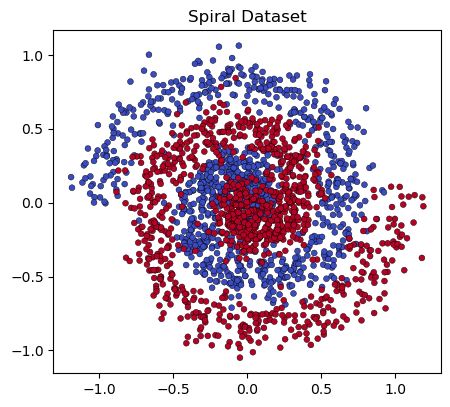

epoch  500  loss=0.4817  acc=0.716
epoch 1000  loss=0.4815  acc=0.721
epoch 1500  loss=0.4815  acc=0.721
epoch 2000  loss=0.4815  acc=0.717


In [2]:
def make_spirals(n_per_class=1000, noise=0.1):
    """Generate two interleaved spirals in 2D."""
    theta = torch.linspace(0, 3 * np.pi, n_per_class)

    r1 = theta / (3 * np.pi)
    x1 = r1 * torch.cos(theta) + noise * torch.randn(n_per_class)
    y1 = r1 * torch.sin(theta) + noise * torch.randn(n_per_class)

    r2 = theta / (3 * np.pi)
    x2 = r2 * torch.cos(theta + np.pi) + noise * torch.randn(n_per_class)
    y2 = r2 * torch.sin(theta + np.pi) + noise * torch.randn(n_per_class)

    X = torch.stack([torch.cat([x1, x2]), torch.cat([y1, y2])], dim=1)
    y = torch.cat([torch.zeros(n_per_class), torch.ones(n_per_class)]).long()
    return X, y


X, y = make_spirals()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=y.numpy(), cmap="coolwarm",
           edgecolors="k", linewidths=0.3, s=18)
ax.set_aspect("equal")
ax.set_title("Spiral Dataset")
plt.show()

# --- define and train ---
spiral_model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 8),
    nn.ReLU(),
    nn.Linear(8, 2),
)

optimizer = torch.optim.Adam(spiral_model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(1, 2001):
    logits = spiral_model(X)
    loss = loss_fn(logits, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        acc = (logits.argmax(dim=1) == y).float().mean()
        print(f"epoch {epoch:>4d}  loss={loss.item():.4f}  acc={acc.item():.3f}")

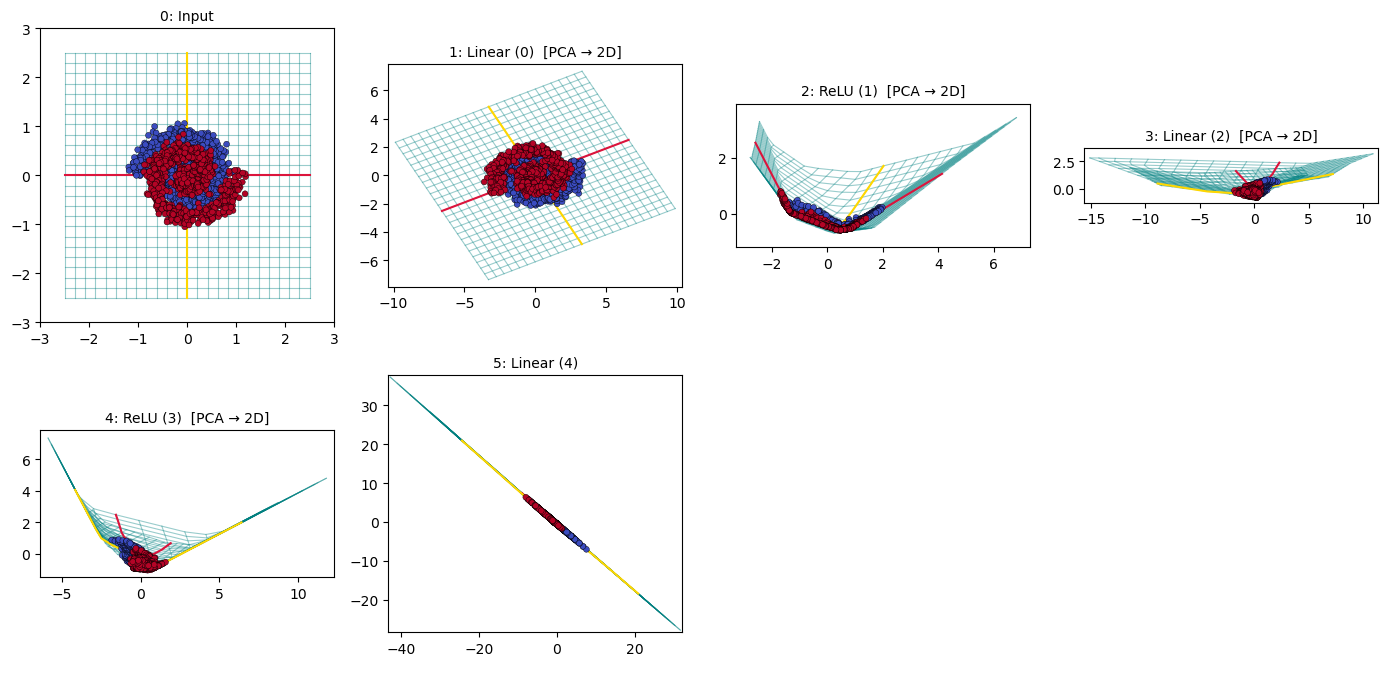

interactive(children=(IntSlider(value=0, description='Layer:', max=5), Output()), _dom_classes=('widget-intera…

In [3]:
plot_all_stages(spiral_model, points=X, labels=y)
visualize_space_transformation(spiral_model, points=X, labels=y)

## Concentric Rings

Here we do the same task but with multiple classes and different data shape.


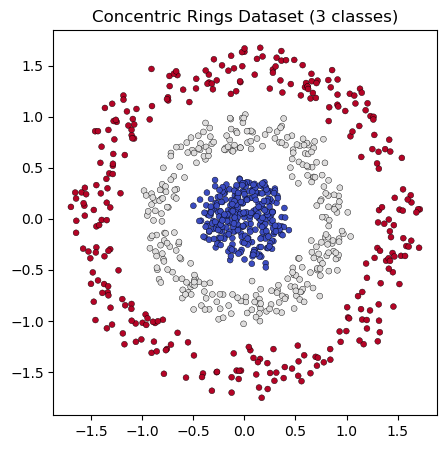

epoch  500  loss=0.0002  acc=1.000
epoch 1000  loss=0.0001  acc=1.000
epoch 1500  loss=0.0000  acc=1.000
epoch 2000  loss=0.0000  acc=1.000


In [4]:
def make_rings(n_per_class=300, noise=0.05):
    """Inner disk (class 0) + middle ring (class 1) + outer ring (class 2)."""
    # inner disk: radius in [0, 0.4)
    r0 = 0.4 * torch.sqrt(torch.rand(n_per_class))
    t0 = 2 * np.pi * torch.rand(n_per_class)
    x0 = r0 * torch.cos(t0) + noise * torch.randn(n_per_class)
    y0 = r0 * torch.sin(t0) + noise * torch.randn(n_per_class)

    # middle ring: radius in [0.7, 1.0)
    r1 = 0.7 + 0.3 * torch.rand(n_per_class)
    t1 = 2 * np.pi * torch.rand(n_per_class)
    x1 = r1 * torch.cos(t1) + noise * torch.randn(n_per_class)
    y1 = r1 * torch.sin(t1) + noise * torch.randn(n_per_class)

    # outer ring: radius in [1.3, 1.7)
    r2 = 1.3 + 0.4 * torch.rand(n_per_class)
    t2 = 2 * np.pi * torch.rand(n_per_class)
    x2 = r2 * torch.cos(t2) + noise * torch.randn(n_per_class)
    y2 = r2 * torch.sin(t2) + noise * torch.randn(n_per_class)

    X = torch.stack([torch.cat([x0, x1, x2]),
                     torch.cat([y0, y1, y2])], dim=1)
    y = torch.cat([torch.zeros(n_per_class),
                   torch.ones(n_per_class),
                   2 * torch.ones(n_per_class)]).long()
    return X, y


X_rings, y_rings = make_rings()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_rings[:, 0].numpy(), X_rings[:, 1].numpy(),
           c=y_rings.numpy(), cmap="coolwarm", edgecolors="k", linewidths=0.3, s=18)
ax.set_aspect("equal")
ax.set_title("Concentric Rings Dataset (3 classes)")
plt.show()

# --- define and train ---
ring_model = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 3),
)

optimizer = torch.optim.Adam(ring_model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(1, 2001):
    logits = ring_model(X_rings)
    loss = loss_fn(logits, y_rings)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        acc = (logits.argmax(dim=1) == y_rings).float().mean()
        print(f"epoch {epoch:>4d}  loss={loss.item():.4f}  acc={acc.item():.3f}")

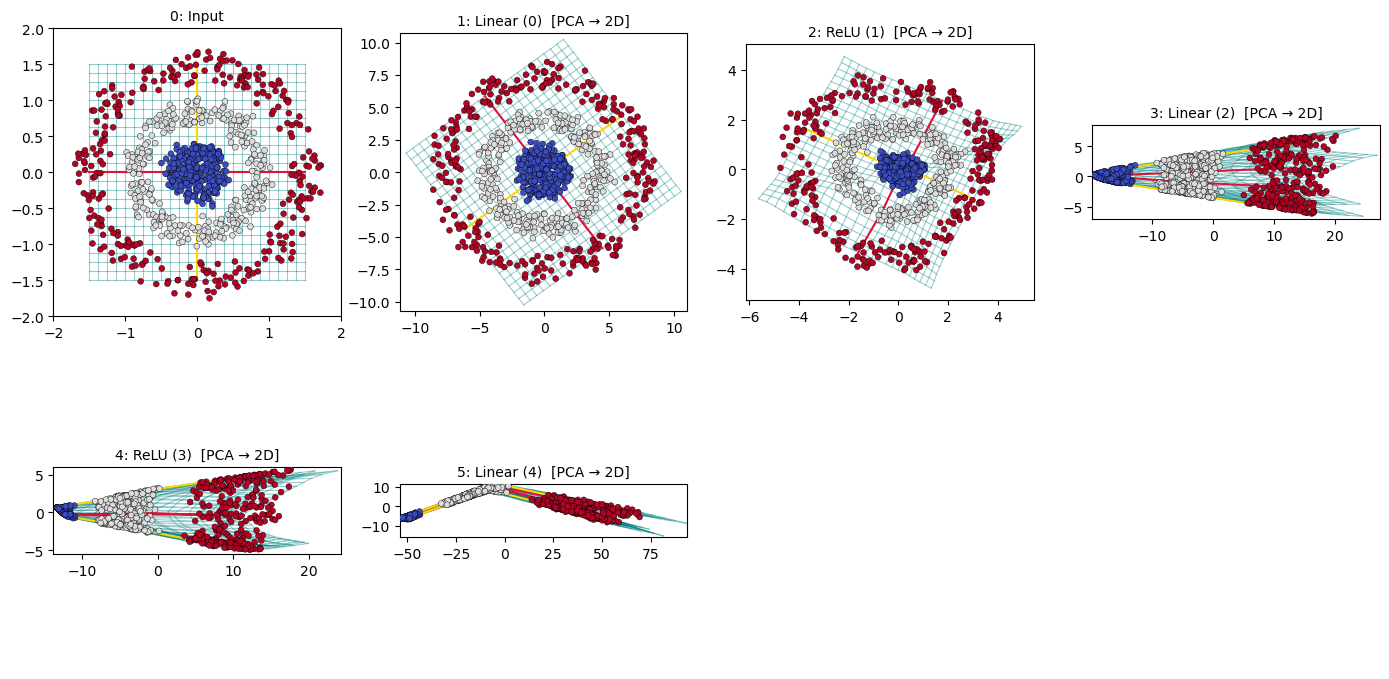

interactive(children=(IntSlider(value=0, description='Layer:', max=5), Output()), _dom_classes=('widget-intera…

In [5]:
plot_all_stages(ring_model, size=1.5, points=X_rings, labels=y_rings)
visualize_space_transformation(ring_model, size=1.5, points=X_rings, labels=y_rings)

##  Radial Wave

Here is a regression example. Notice how the number line that the model learns naturally separates the points by their values.

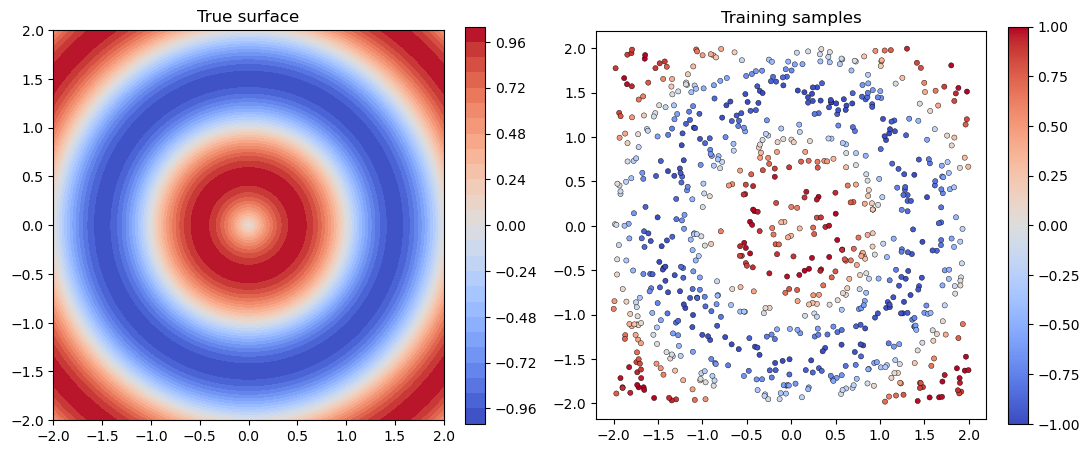

epoch  500  mse=0.00331
epoch 1000  mse=0.00210
epoch 1500  mse=0.00172
epoch 2000  mse=0.00131
epoch 2500  mse=0.00031
epoch 3000  mse=0.00017


In [6]:
def radial_wave(X):
    """f(x1, x2) = sin(pi * sqrt(x1^2 + x2^2))"""
    return torch.sin(np.pi * torch.sqrt(X[:, 0] ** 2 + X[:, 1] ** 2))


# --- sample training data ---
n_reg = 800
X_reg = 4.0 * torch.rand(n_reg, 2) - 2.0          # uniform in [-2, 2]²
y_reg = radial_wave(X_reg)

# --- show the true surface + sampled points ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# contour of true function
grid_vis = 120
xv = np.linspace(-2, 2, grid_vis)
yv = np.linspace(-2, 2, grid_vis)
xxv, yyv = np.meshgrid(xv, yv)
zv = np.sin(np.pi * np.sqrt(xxv ** 2 + yyv ** 2))
cf = axes[0].contourf(xxv, yyv, zv, levels=30, cmap="coolwarm")
axes[0].set_aspect("equal")
axes[0].set_title("True surface")
fig.colorbar(cf, ax=axes[0], fraction=0.046)

# sampled points
sc = axes[1].scatter(X_reg[:, 0].numpy(), X_reg[:, 1].numpy(),
                     c=y_reg.numpy(), cmap="coolwarm", edgecolors="k",
                     linewidths=0.3, s=14, vmin=-1, vmax=1)
axes[1].set_aspect("equal")
axes[1].set_title("Training samples")
fig.colorbar(sc, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

# --- define and train ---
reg_model = nn.Sequential(
    nn.Linear(2, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)

optimizer = torch.optim.Adam(reg_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(1, 3001):
    pred = reg_model(X_reg).squeeze()
    loss = loss_fn(pred, y_reg)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"epoch {epoch:>4d}  mse={loss.item():.5f}")

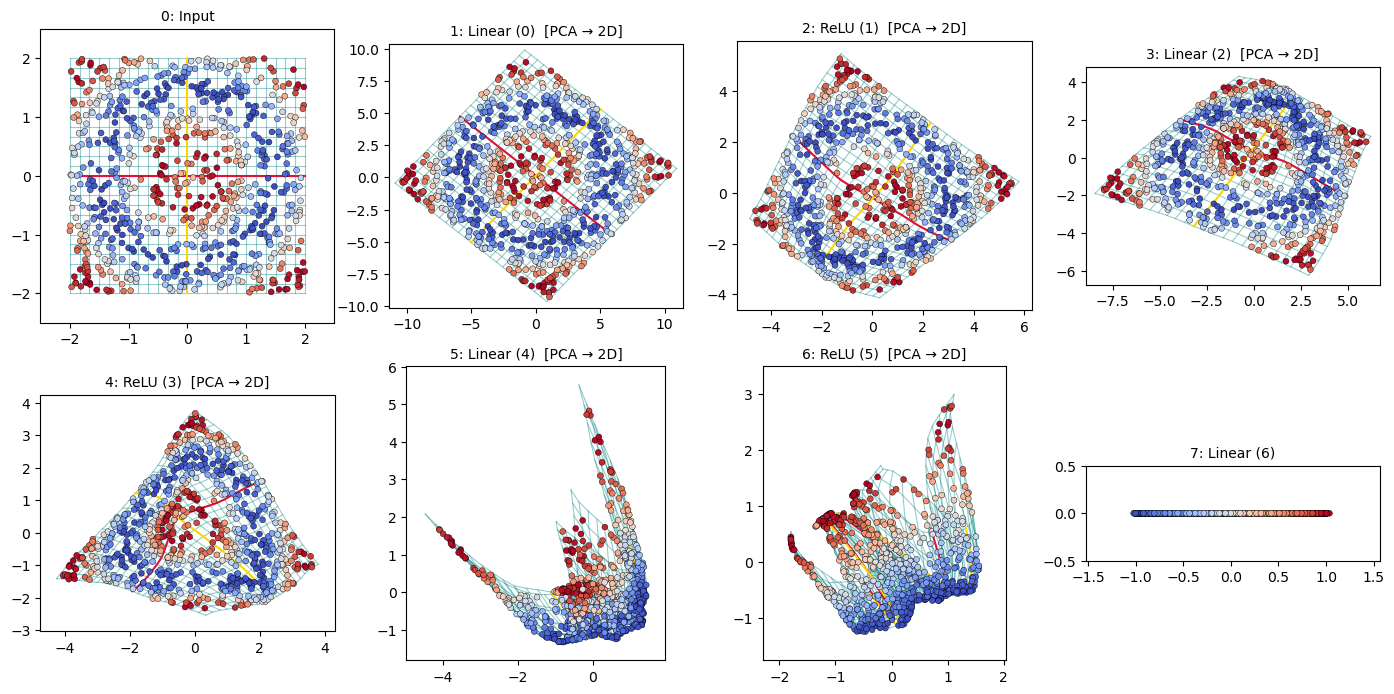

interactive(children=(IntSlider(value=0, description='Layer:', max=7), Output()), _dom_classes=('widget-intera…

In [7]:
plot_all_stages(reg_model, size=2.0, points=X_reg, labels=y_reg)
visualize_space_transformation(reg_model, size=2.0, points=X_reg, labels=y_reg)

## XOR

One of my professors at UCLA actually wrote a paper about how deep networks are able to create more linear regions than wide ones. I've only skimmed the paper, but this sort of visual comparison of how wide vs. deep networks function seem right up that alley. Here is the paper: https://scholar.google.com/citations?view_op=view_citation&hl=en&user=pDIuuVwAAAAJ&citation_for_view=pDIuuVwAAAAJ:hqOjcs7Dif8C

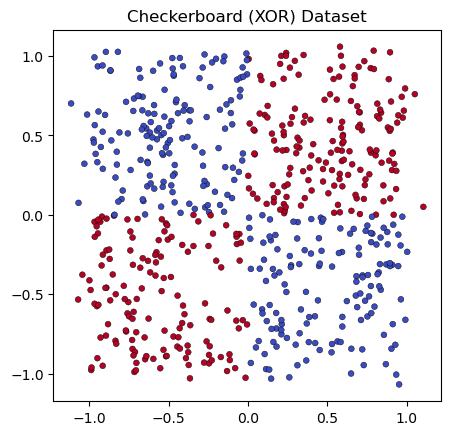

Wide params: 642   Deep params: 1170

Training wide model:
  epoch 1000  loss=0.0067  acc=1.000
  epoch 2000  loss=0.0027  acc=1.000
  epoch 3000  loss=0.0013  acc=1.000

Training deep model:
  epoch 1000  loss=0.0006  acc=1.000
  epoch 2000  loss=0.0001  acc=1.000
  epoch 3000  loss=0.0000  acc=1.000


In [8]:
def make_checkerboard(n=600, noise=0.05):
    """2x2 XOR checkerboard: class 1 when sign(x1) == sign(x2), else class 0."""
    X = 2.0 * torch.rand(n, 2) - 1.0  # uniform in [-1, 1]²
    X += noise * torch.randn_like(X)
    y = ((X[:, 0] * X[:, 1]) > 0).long()
    return X, y


X_cb, y_cb = make_checkerboard()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_cb[:, 0].numpy(), X_cb[:, 1].numpy(),
           c=y_cb.numpy(), cmap="coolwarm", edgecolors="k", linewidths=0.3, s=18)
ax.set_aspect("equal")
ax.set_title("Checkerboard (XOR) Dataset")
plt.show()

# ---- wide: 1 hidden layer, 128 neurons ----
wide_model = nn.Sequential(
    nn.Linear(2, 128),
    nn.ReLU(),
    nn.Linear(128, 2),
)

# ---- deep: 5 hidden layers, 16 neurons each ----
deep_model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 2),
)

def train(model, X, y, epochs=3000, lr=1e-2):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for epoch in range(1, epochs + 1):
        logits = model(X)
        loss = loss_fn(logits, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if epoch % 1000 == 0:
            acc = (logits.argmax(1) == y).float().mean()
            print(f"  epoch {epoch:>4d}  loss={loss.item():.4f}  acc={acc.item():.3f}")

n_wide = sum(p.numel() for p in wide_model.parameters())
n_deep = sum(p.numel() for p in deep_model.parameters())
print(f"Wide params: {n_wide}   Deep params: {n_deep}\n")

print("Training wide model:")
train(wide_model, X_cb, y_cb)
print("\nTraining deep model:")
train(deep_model, X_cb, y_cb)

=== Wide model (1 hidden layer, 128 neurons) ===


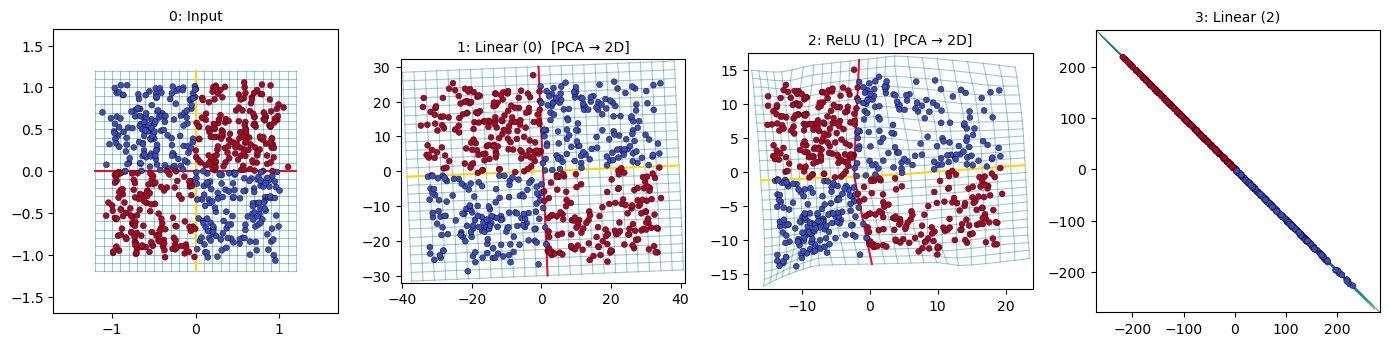


=== Deep model (5 hidden layers, 16 neurons each) ===


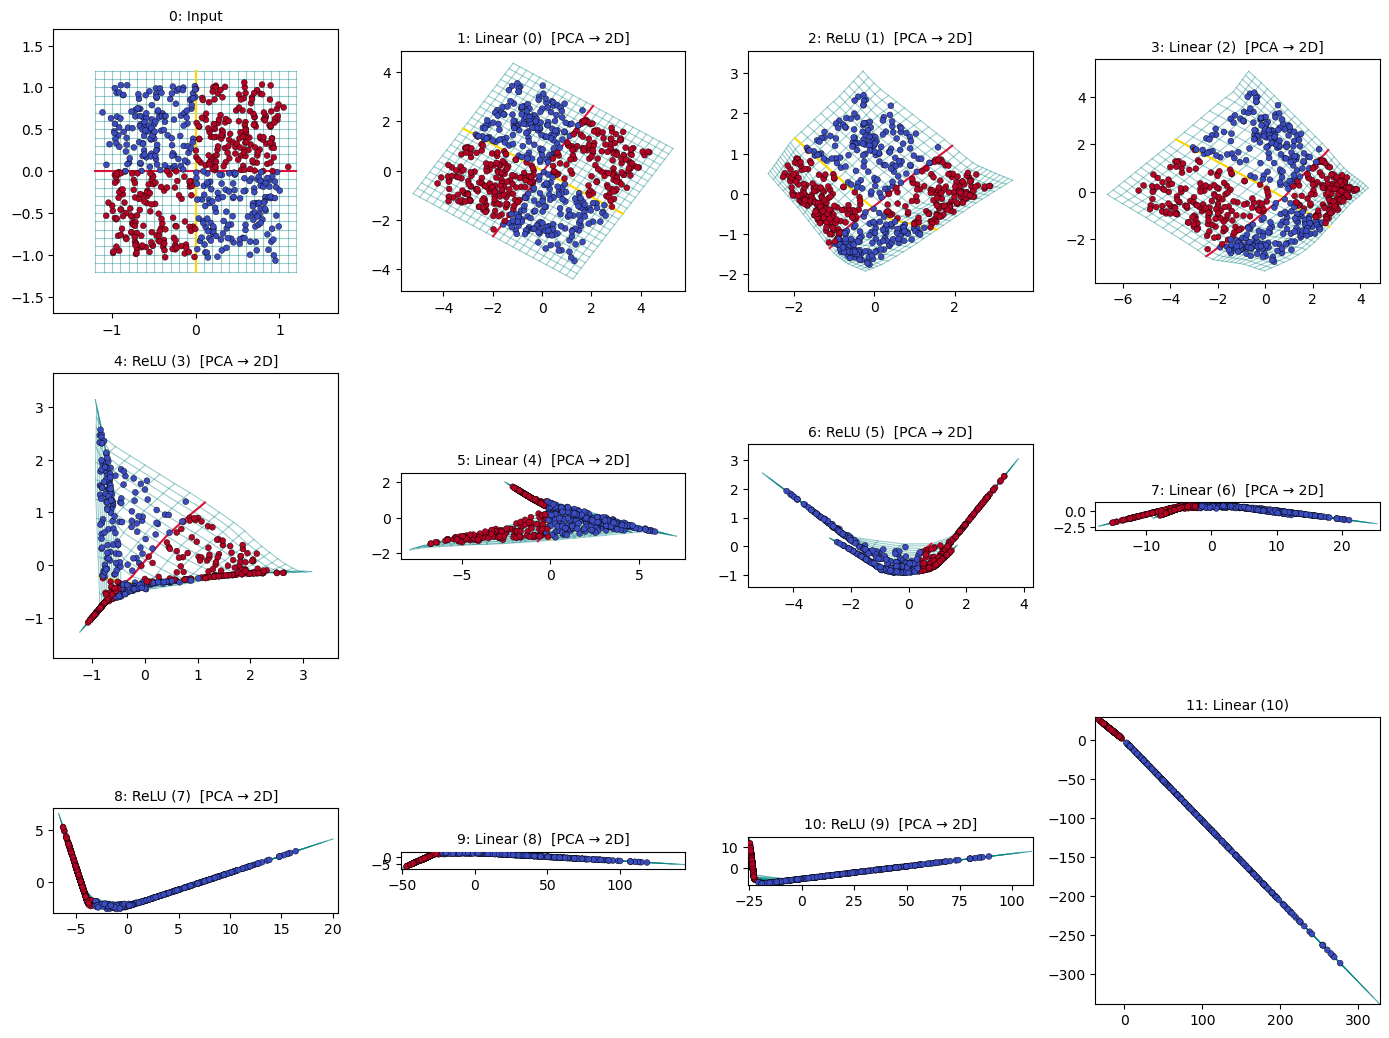

In [9]:
print("=== Wide model (1 hidden layer, 128 neurons) ===")
plot_all_stages(wide_model, size=1.2, points=X_cb, labels=y_cb)

print("\n=== Deep model (5 hidden layers, 16 neurons each) ===")
plot_all_stages(deep_model, size=1.2, points=X_cb, labels=y_cb)